# MobileNet — Etapa 4: Ajuste de Hiperparâmetros

Este notebook busca a melhor configuração do MLP usando **RandomizedSearchCV** seguido de um **GridSearchCV** refinado, comparando o resultado com o modelo baseline da Etapa 2.

---

## 1. Importações e Preparação dos Dados

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')

IMAGES_DIR = '../images/evaluation'
os.makedirs(IMAGES_DIR, exist_ok=True)

In [2]:
train = pd.read_csv('../data/train.csv')

X = train.drop(columns='faixa_preco')
y = train['faixa_preco']

X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val   = scaler.transform(X_val_raw)

print(f'Treino:    {X_train.shape}')
print(f'Validação: {X_val.shape}')

Treino:    (1600, 20)
Validação: (400, 20)


---
## 2. Modelo Baseline

Registramos as métricas do modelo da Etapa 2 como referência para comparação.

In [3]:
baseline = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    max_iter=500,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20
)
baseline.fit(X_train, y_train)

acc_base = accuracy_score(y_val, baseline.predict(X_val))
f1_base  = f1_score(y_val, baseline.predict(X_val), average='macro')

print(f'Baseline — Acurácia: {acc_base:.4f} | F1-macro: {f1_base:.4f}')

Baseline — Acurácia: 0.9200 | F1-macro: 0.9198


---
## 3. Ajuste de Hiperparâmetros

### 3.1 Conceito

Os **hiperparâmetros** são configurações definidas antes do treinamento — ao contrário dos pesos, que são aprendidos durante o treino. A escolha inadequada pode levar a underfitting (modelo simples demais) ou overfitting (modelo complexo demais).

Hiperparâmetros investigados:

| Hiperparâmetro       | Descrição                                              |
|----------------------|--------------------------------------------------------|
| `hidden_layer_sizes` | Número de camadas ocultas e neurônios por camada       |
| `activation`         | Função de ativação nas camadas ocultas                 |
| `alpha`              | Regularização L2 — penaliza pesos grandes              |
| `learning_rate_init` | Taxa de aprendizado inicial do Adam                    |
| `max_iter`           | Número máximo de épocas de treinamento                 |

### 3.2 Regularização L2

O parâmetro `alpha` adiciona um termo de penalização à função de perda para evitar overfitting:

$$\mathcal{L}_{\text{reg}} = \mathcal{L} + \alpha \sum_{l} \|W^{(l)}\|_2^2$$

Valores maiores de $\alpha$ penalizam pesos grandes, simplificando o modelo; valores menores permitem maior complexidade.

### 3.3 Estratégia: RandomizedSearchCV → GridSearchCV

A busca é feita em duas etapas:

1. **RandomizedSearchCV:** explora aleatoriamente um espaço amplo de combinações com validação cruzada (k=3). Eficiente para identificar regiões promissoras sem testar todas as combinações.
2. **GridSearchCV:** busca exaustiva em torno dos melhores parâmetros encontrados na etapa anterior para refinamento final.

In [4]:
# Espaço de busca amplo para o RandomizedSearchCV
espaco_busca = {
    'hidden_layer_sizes': [
        (64,), (128,), (256,),
        (64, 32), (128, 64), (256, 128),
        (128, 64, 32), (256, 128, 64)
    ],
    'activation':         ['relu', 'tanh'],
    'alpha':              [0.0001, 0.001, 0.01, 0.1],
    'learning_rate_init': [0.001, 0.005, 0.01],
    'max_iter':           [300, 500]
}

mlp_base = MLPClassifier(solver='adam', random_state=42, early_stopping=True,
                         validation_fraction=0.1, n_iter_no_change=20)

busca_aleatoria = RandomizedSearchCV(
    estimator=mlp_base,
    param_distributions=espaco_busca,
    n_iter=40,          # 40 combinações aleatórias
    cv=3,               # validação cruzada com 3 folds
    scoring='f1_macro', # métrica de otimização
    n_jobs=-1,          # usa todos os núcleos disponíveis
    random_state=42,
    verbose=1
)

busca_aleatoria.fit(X_train, y_train)

print('\nMelhores parâmetros (busca aleatória):')
print(busca_aleatoria.best_params_)
print(f'Melhor F1-macro (CV): {busca_aleatoria.best_score_:.4f}')

Fitting 3 folds for each of 40 candidates, totalling 120 fits



Melhores parâmetros (busca aleatória):
{'max_iter': 500, 'learning_rate_init': 0.001, 'hidden_layer_sizes': (256, 128), 'alpha': 0.1, 'activation': 'tanh'}
Melhor F1-macro (CV): 0.9511


### 3.4 Refinamento com GridSearchCV

Com base nos melhores parâmetros encontrados, realizamos uma busca exaustiva em uma grade menor e mais focada.

In [5]:
p = busca_aleatoria.best_params_

# Grade refinada em torno dos melhores valores encontrados
grade_refinada = {
    'hidden_layer_sizes': [p['hidden_layer_sizes']],
    'activation':         [p['activation']],
    'alpha':              sorted(set([
        max(0.0001, p['alpha'] / 10),
        p['alpha'],
        p['alpha'] * 10
    ])),
    'learning_rate_init': sorted(set([
        max(0.0001, p['learning_rate_init'] / 5),
        p['learning_rate_init'],
        min(0.05, p['learning_rate_init'] * 5)
    ])),
    'max_iter': [500]
}

busca_grade = GridSearchCV(
    estimator=mlp_base,
    param_grid=grade_refinada,
    cv=5,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

busca_grade.fit(X_train, y_train)

print('\nMelhores parâmetros (grade refinada):')
print(busca_grade.best_params_)
print(f'Melhor F1-macro (CV): {busca_grade.best_score_:.4f}')

Fitting 5 folds for each of 9 candidates, totalling 45 fits



Melhores parâmetros (grade refinada):
{'activation': 'tanh', 'alpha': 0.1, 'hidden_layer_sizes': (256, 128), 'learning_rate_init': 0.001, 'max_iter': 500}
Melhor F1-macro (CV): 0.9510


---
## 4. Análise dos Resultados da Busca

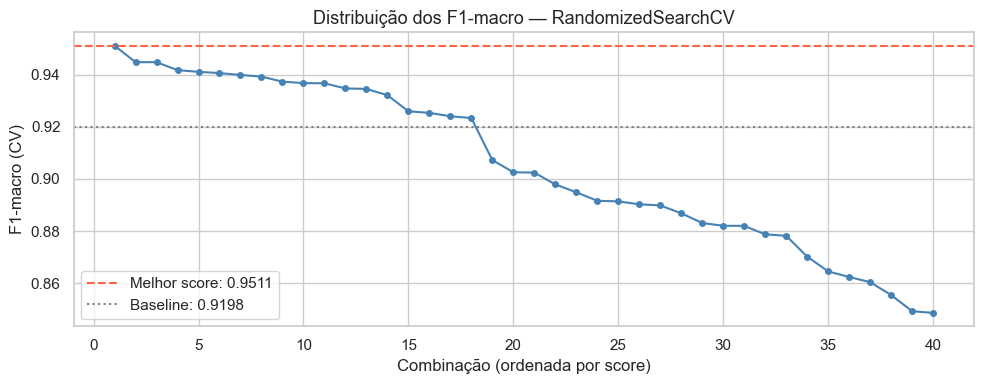

In [6]:
# Distribuição dos scores de todas as combinações testadas na busca aleatória
resultados_cv = pd.DataFrame(busca_aleatoria.cv_results_)
scores = resultados_cv['mean_test_score'].sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(1, len(scores) + 1), scores.values,
        marker='o', markersize=4, linewidth=1.5, color='steelblue')
ax.axhline(y=busca_aleatoria.best_score_, color='tomato', linestyle='--',
           linewidth=1.5, label=f'Melhor score: {busca_aleatoria.best_score_:.4f}')
ax.axhline(y=f1_base, color='gray', linestyle=':', linewidth=1.5,
           label=f'Baseline: {f1_base:.4f}')
ax.set_title('Distribuição dos F1-macro — RandomizedSearchCV', fontsize=13)
ax.set_xlabel('Combinação (ordenada por score)')
ax.set_ylabel('F1-macro (CV)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/03_hyperparam_search.png', dpi=150)
plt.show()

---
## 5. Comparação: Baseline vs. Melhor Modelo

In [7]:
# Avaliação do melhor modelo no conjunto de validação
melhor_modelo = busca_grade.best_estimator_
y_pred_melhor = melhor_modelo.predict(X_val)

acc_melhor = accuracy_score(y_val, y_pred_melhor)
f1_melhor  = f1_score(y_val, y_pred_melhor, average='macro')

print('Relatório — Melhor Modelo:\n')
print(classification_report(
    y_val, y_pred_melhor,
    target_names=['Baixo custo', 'Custo médio', 'Alto custo', 'Custo muito alto']
))

Relatório — Melhor Modelo:

                  precision    recall  f1-score   support

     Baixo custo       0.99      0.97      0.98       100
     Custo médio       0.93      0.95      0.94       100
      Alto custo       0.93      0.93      0.93       100
Custo muito alto       0.97      0.97      0.97       100

        accuracy                           0.95       400
       macro avg       0.96      0.96      0.96       400
    weighted avg       0.96      0.95      0.96       400



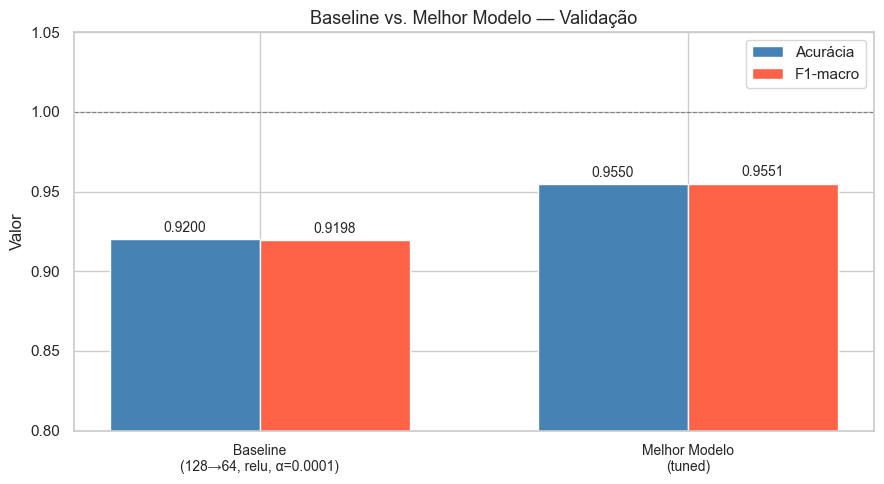


Ganho em acurácia: +3.50 p.p.
Ganho em F1-macro: +3.53 p.p.


In [8]:
# Gráfico comparativo de acurácia e F1-macro
modelos   = ['Baseline\n(128→64, relu, α=0.0001)', 'Melhor Modelo\n(tuned)']
acuracias = [acc_base, acc_melhor]
f1_scores = [f1_base, f1_melhor]

x = np.arange(len(modelos))
largura = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
barras_acc = ax.bar(x - largura / 2, acuracias, largura,
                    label='Acurácia', color='steelblue')
barras_f1  = ax.bar(x + largura / 2, f1_scores, largura,
                    label='F1-macro', color='tomato')

ax.bar_label(barras_acc, fmt='%.4f', padding=3, fontsize=10)
ax.bar_label(barras_f1,  fmt='%.4f', padding=3, fontsize=10)

ax.set_title('Baseline vs. Melhor Modelo — Validação', fontsize=13)
ax.set_ylabel('Valor')
ax.set_ylim(0.8, 1.05)
ax.set_xticks(x)
ax.set_xticklabels(modelos, fontsize=10)
ax.legend()
ax.axhline(y=1.0, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig(f'{IMAGES_DIR}/04_model_comparison.png', dpi=150)
plt.show()

print(f'\nGanho em acurácia: {(acc_melhor - acc_base)*100:+.2f} p.p.')
print(f'Ganho em F1-macro: {(f1_melhor - f1_base)*100:+.2f} p.p.')

---
## 6. Resumo

| Parâmetro               | Baseline         | Melhor Modelo |
|-------------------------|------------------|---------------|
| `hidden_layer_sizes`    | (128, 64)        | —             |
| `activation`            | relu             | —             |
| `alpha`                 | 0.0001           | —             |
| `learning_rate_init`    | 0.001            | —             |
| Acurácia (validação)    | —                | —             |
| F1-macro (validação)    | —                | —             |

> Os valores da coluna *Melhor Modelo* serão preenchidos após execução das células acima.

O melhor modelo encontrado segue para a **Etapa 5**, onde será aplicado ao conjunto de teste para as predições finais.